In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
np.random.seed(42)

# Generate synthetic data
apple_weights = np.random.uniform(70, 200, 100)
orange_weights = np.random.uniform(130, 300, 100)

# Create DataFrame (0 = apple, 1 = orange)
data = pd.DataFrame({
    'weight': np.concatenate([apple_weights, orange_weights]),
    'fruit': np.concatenate([np.zeros(100), np.ones(100)])
})

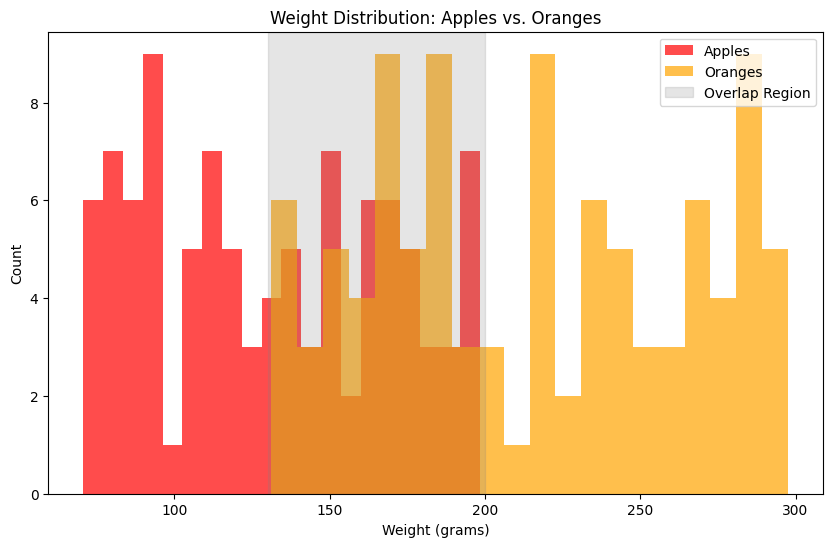

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(data[data['fruit'] == 0]['weight'], bins=20, alpha=0.7, label='Apples', color='red')
plt.hist(data[data['fruit'] == 1]['weight'], bins=20, alpha=0.7, label='Oranges', color='orange')
plt.axvspan(130, 200, color='gray', alpha=0.2, label='Overlap Region')
plt.title('Weight Distribution: Apples vs. Oranges')
plt.xlabel('Weight (grams)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [12]:
X = data[['weight']]
y = data['fruit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [14]:
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=['Apple', 'Orange'])

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Display model coefficients
print(f"\nModel Equation: log(odds) = {model.intercept_[0]:.2f} + {model.coef_[0][0]:.2f} * weight")

Accuracy: 0.75

Confusion Matrix:
[[17  4]
 [ 6 13]]

Classification Report:
              precision    recall  f1-score   support

       Apple       0.74      0.81      0.77        21
      Orange       0.76      0.68      0.72        19

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.75      0.75      0.75        40


Model Equation: log(odds) = -7.59 + 0.04 * weight


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


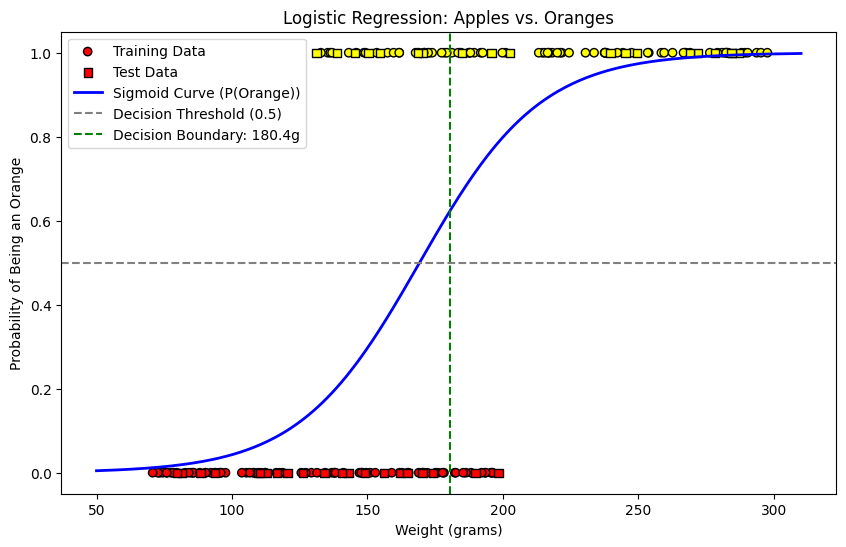

In [15]:
# Generate predictions for the sigmoid curve
weight_range = np.linspace(50, 310, 300).reshape(-1, 1)
probabilities = model.predict_proba(weight_range)[:, 1]  # P(Orange)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, c=y_train, cmap='autumn', edgecolor='k', label='Training Data')
plt.scatter(X_test, y_test, c=y_test, cmap='autumn', edgecolor='k', marker='s', label='Test Data')
plt.plot(weight_range, probabilities, color='blue', linewidth=2, label='Sigmoid Curve (P(Orange))')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Threshold (0.5)')

# Calculate decision boundary (where P(Orange) = 0.5)
decision_boundary = (0.5 - model.intercept_[0]) / model.coef_[0][0]
plt.axvline(decision_boundary, color='green', linestyle='--', label=f'Decision Boundary: {decision_boundary:.1f}g')

plt.title('Logistic Regression: Apples vs. Oranges')
plt.xlabel('Weight (grams)')
plt.ylabel('Probability of Being an Orange')
plt.legend()
plt.show()

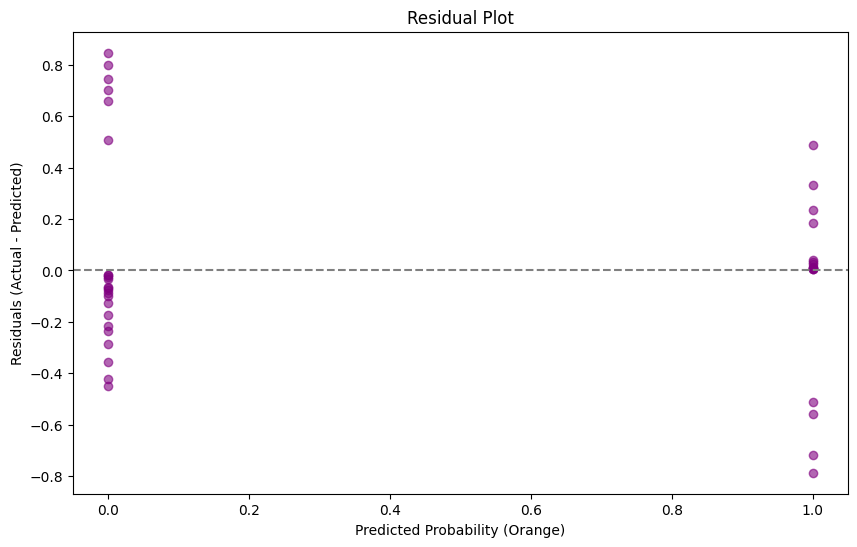

In [16]:
residuals = y_test - model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Probability (Orange)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()